# =============================================================================
# BASELINE DENSENET121 — TRAIN-VAL-TEST SPLIT EVALUATION
# =============================================================================
Evaluates the baseline DenseNet121 (frozen backbone → binary classification) on
**per-dataset** splits at configurable **train-val-test** ratios (60:20:20, 65:18:18, 70:15:15).

Dataset: **CEDAR**

**Prerequisites:**
1. Run `scripts/prepare_split_ratios.py` to generate split JSONs.

# =============================================================================
# STEP 1: SETUP, IMPORTS, AND REPRODUCIBILITY
# =============================================================================

In [1]:
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# Set repo root
current_dir = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Import Custom Modules
from models.feature_extractor import DenseNetFeatureExtractor
from utils.model_evaluation import compute_metrics, _plot_det_curve, _plot_far_frr, _plot_confusion_matrix, _plot_score_distribution, _plot_roc_curve
from dataloader.tDCBAM_trainloader import get_transforms

# Deterministic Seeding
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" > [System] Seed set to: {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [System] Device: {DEVICE}")
print(f" > [System] CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" > [System] CUDA Device Name: {torch.cuda.get_device_name()}")

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [System] Seed set to: 42
 > [System] Device: cuda
 > [System] CUDA Available: True
 > [System] CUDA Device Name: NVIDIA GeForce RTX 5080


# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================

In [2]:
# Notebook identifier
NOTEBOOK_NAME = 'baseline_cedar'
DATASET       = 'cedar'
DATASET_NAME  = 'CEDAR'

# Paths
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data', 'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'baseline_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals', NOTEBOOK_NAME)

# Split ratios to evaluate
SPLIT_RATIOS = ['70_15_15']

# Training Configuration
# Total = 100 epochs — consistent with the proposed model's 30+70 budget.
# AdamW (not SGD) with the same weight_decay, betas, and scheduler settings
# as the proposed model's Phase 1, so comparisons are fair.
EPOCHS       = 100
BATCH_SIZE   = 32           # aligned with proposed PRETRAIN_BATCH_SIZE
LR           = 1e-3         # same as proposed META_LR_PHASE1
WEIGHT_DECAY = 1e-2         # same as proposed META_WEIGHT_DECAY
MOMENTUM     = 0.9          # AdamW beta1 (standard default)

# Data Configuration
INPUT_SHAPE  = (224, 224)
IMG_SIZE     = 224
NUM_WORKERS  = 4

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print(" > Configuration loaded:")
print(f"   Dataset       : {DATASET_NAME}")
print(f"   Split Ratios  : {SPLIT_RATIOS}")
print(f"   Epochs        : {EPOCHS}")
print(f"   Batch Size    : {BATCH_SIZE}")
print(f"   Learning Rate : {LR}")
print(f"   Weight Decay  : {WEIGHT_DECAY}")
print(f"   Image Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Checkpoint Dir: {CHECKPOINT_DIR}")
print(f"   Eval Dir      : {EVAL_DIR}")

 > Configuration loaded:
   Dataset       : CEDAR
   Split Ratios  : ['70_15_15']
   Epochs        : 100
   Batch Size    : 32
   Learning Rate : 0.001
   Weight Decay  : 0.01
   Image Size    : 224x224
   Checkpoint Dir: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits
   Eval Dir      : /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar


# =============================================================================
# STEP 3: GENERATE SPLITS (if not already generated)
# =============================================================================

# =============================================================================
# STEP 4: DATASET CLASS AND TRANSFORMS
# =============================================================================

In [3]:
class SplitDataset(Dataset):
    """
    Binary classification dataset (Genuine=0, Forged=1) from split JSON.
    Works with CEDAR, BHSig-Bengali, and BHSig-Hindi split files.

    Labels:
        0 = Genuine
        1 = Forged

    The transform is passed in at construction time — a separate transform
    is instantiated for train vs val/test via get_transforms(mode=...) so
    augmentation is only applied during training.
    """
    def __init__(self, user_dict, transform=None):
        self.samples   = []
        self.transform = transform

        for uid, data in user_dict.items():
            # Handle both key styles: 'genuine'/'forged' and 'gen'/'forg'
            gen_key  = next((k for k in data.keys() if k.lower() in ['genuine', 'gen']),  None)
            forg_key = next((k for k in data.keys() if k.lower() in ['forged', 'forgeries', 'forg']), None)

            if gen_key:
                for path in data[gen_key]:
                    self.samples.append((path, 0))   # 0 = Genuine
            if forg_key:
                for path in data[forg_key]:
                    self.samples.append((path, 1))   # 1 = Forged

        num_gen  = sum(1 for _, l in self.samples if l == 0)
        num_forg = sum(1 for _, l in self.samples if l == 1)
        print(f"   Dataset: {len(self.samples)} samples "
              f"({num_gen} genuine + {num_forg} forged) from {len(user_dict)} users")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except Exception as e:
            print(f"   WARNING: Failed to load {img_path}: {e}")
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label


# get_transforms(mode) returns a single Compose object — NOT a tuple.
# Use mode='train' for training data (applies augmentation).
# Use mode='val'   for validation and test data (no augmentation).
# This mirrors exactly how prototype_cedar.ipynb constructs transforms for
# SplitEpisodicDataset — ensuring identical preprocessing across both models.
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > Dataset class and transforms defined")
print(f"   train_transform: augmentation ON  (dilation p=0.5 + geometric)")
print(f"   val_transform  : augmentation OFF (preprocessing only)")

 > Dataset class and transforms defined
   train_transform: augmentation ON  (dilation p=0.5 + geometric)
   val_transform  : augmentation OFF (preprocessing only)


# =============================================================================
# STEP 5: TRAINING UTILITIES
# =============================================================================

In [4]:
def initialize_baseline_model(device):
    """Initialize DenseNet121 baseline with ImageNet pretrained weights."""
    num_classes = 2
    model = DenseNetFeatureExtractor(
        backbone_name='densenet121', output_dim=num_classes,
        pretrained=True, baseline=True
    ).to(device)
    print(f"   Using ImageNet initialization | output_dim={num_classes}")
    return model


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_model(model, loader, device, output_dir=None, silent=False):
    """Evaluate model and compute EER, AUC, Accuracy, Precision, Recall, F1."""
    model.eval()
    all_labels, all_scores = [], []

    iter_bar = tqdm(loader, desc="Evaluating", leave=False) if not silent else loader

    with torch.no_grad():
        for images, labels in iter_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # Softmax probability of class 1 (Forged) used as the anomaly score.
            # compute_metrics() expects higher score → more likely forged.
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_scores)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        print(f"EER            : {metrics['eer']:.2%}")
        print(f"AUC            : {metrics['auc']:.4f}")
        print(f"Best Threshold : {metrics.get('threshold', 0):.4f}")
        print(f"Accuracy       : {metrics['accuracy']:.2%}")
        print(f"Precision      : {metrics.get('precision', 0):.2%}")
        print(f"Recall         : {metrics.get('recall', 0):.2%}")
        print(f"F1-Score       : {metrics.get('f1', 0):.2%}")
        print("=" * 40)

        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


def train_full_pipeline(model, train_loader, val_loader, device,
                        epochs, lr, weight_decay, checkpoint_path):
    """
    Train with AdamW + ReduceLROnPlateau. Selects best model by val EER.

    Optimizer and scheduler settings are matched to the proposed model's
    meta-training Phase 1 configuration for a fair comparison:
        AdamW  : lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999)
        Scheduler: ReduceLROnPlateau(mode='min', factor=0.8, patience=8)
                   monitoring val EER — same as proposed Phase 1 scheduler.

    Args:
        model: DenseNetFeatureExtractor in baseline mode.
        train_loader / val_loader: DataLoaders.
        device: torch.device.
        epochs (int): Total training epochs.
        lr (float): Initial learning rate.
        weight_decay (float): AdamW weight decay.
        checkpoint_path (str): Path to save best checkpoint.

    Returns:
        dict: Best validation metrics.
    """
    criterion = nn.CrossEntropyLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}

    # AdamW with same weight_decay as proposed model for a fair comparison
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=weight_decay, betas=(0.9, 0.999))
    # Same scheduler config as proposed model Phase 1/2
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=8
    )

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics           = evaluate_model(model, val_loader, device, silent=True)
        val_eer, val_acc      = val_metrics['eer'], val_metrics['accuracy']

        print(f"   Epoch {epoch+1:02d}/{epochs} | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)

        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({
                'model_state_dict': model.state_dict(),
                'metrics': best_metrics
            }, checkpoint_path)
            print(f"   >>> Saved! (Val EER: {val_eer:.2%})")

    return best_metrics


print(" > Training utilities defined")

 > Training utilities defined


# =============================================================================
# STEP 6: RUN ALL SPLIT RATIOS
# =============================================================================

In [5]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file  = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    train_pct, val_pct, test_pct = ratio.split('_')
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{train_pct}-{val_pct}-{test_pct}")
    os.makedirs(split_eval_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f" {DATASET_NAME} -- {train_pct}:{val_pct}:{test_pct} Split")
    print(f"{'='*60}")

    if not os.path.exists(split_file):
        print(f"   SKIPPED: Split file not found: {split_file}")
        continue

    # Load train / val / test dicts from split JSON
    with open(split_file, 'r') as f:
        split_data = json.load(f)

    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']

    print(f"   Train users: {len(train_dict)} | Val users: {len(val_dict)} | Test users: {len(test_dict)}")

    # Build datasets — train uses augmentation, val/test do not.
    # train_transform and val_transform are constructed from get_transforms()
    # above and share the same preprocess_image() pipeline as the proposed model.
    print("   Creating train dataset...")
    train_dataset = SplitDataset(train_dict, transform=train_transform)
    print("   Creating val dataset...")
    val_dataset   = SplitDataset(val_dict,   transform=val_transform)
    print("   Creating test dataset...")
    test_dataset  = SplitDataset(test_dict,  transform=val_transform)

    if len(train_dataset) == 0 or len(val_dataset) == 0 or len(test_dataset) == 0:
        print(f"   SKIPPED: Empty dataset for ratio {ratio}")
        continue

    # drop_last=True on train to prevent incomplete batches during training.
    # drop_last=False on val/test to ensure every sample is evaluated.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

    # Reinitialise model and seed for each split — ensures reproducibility
    seed_everything(42)
    model = initialize_baseline_model(DEVICE)

    # Train on train set, model selection on val set
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{DATASET}_{ratio}.pth")
    best_val_metrics = train_full_pipeline(
        model, train_loader, val_loader, DEVICE,
        epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
        checkpoint_path=ckpt_path
    )

    # Reload best checkpoint and evaluate on test set (never seen during training)
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        state = checkpoint.get('model_state_dict', checkpoint)
        model.load_state_dict(state)

    final_test_metrics = evaluate_model(
        model, test_loader, DEVICE, output_dir=split_eval_dir, silent=False
    )

    # Record results
    result_key = f"{DATASET_NAME} ({train_pct}:{val_pct}:{test_pct})"
    all_results[result_key] = {
        'dataset':     DATASET_NAME,
        'split':       f"{train_pct}:{val_pct}:{test_pct}",
        'train_users': len(train_dict),
        'val_users':   len(val_dict),
        'test_users':  len(test_dict),
        'eer':         float(final_test_metrics['eer']),
        'accuracy':    float(final_test_metrics['accuracy']),
        'auc':         float(final_test_metrics['auc']),
        'precision':   float(final_test_metrics.get('precision', 0)),
        'recall':      float(final_test_metrics.get('recall', 0)),
        'f1':          float(final_test_metrics.get('f1', 0)),
    }

    print(f"\n   TEST SET RESULT: EER={final_test_metrics['eer']:.2%} | "
          f"Acc={final_test_metrics['accuracy']:.2%} | "
          f"AUC={final_test_metrics['auc']:.4f} | "
          f"F1={final_test_metrics.get('f1', 0):.4f}")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*60}")


 CEDAR -- 70:15:15 Split
   Train users: 38 | Val users: 8 | Test users: 9
   Creating train dataset...
   Dataset: 1824 samples (912 genuine + 912 forged) from 38 users
   Creating val dataset...
   Dataset: 384 samples (192 genuine + 192 forged) from 8 users
   Creating test dataset...
   Dataset: 432 samples (216 genuine + 216 forged) from 9 users
 > [System] Seed set to: 42
   Using ImageNet initialization | output_dim=2


Training:   0%|          | 0/57 [00:00<?, ?it/s]

   Epoch 01/100 | Loss: 0.6323 | Acc: 68.75% | Val EER: 41.15% | Val Acc: 58.59%
   >>> Saved! (Val EER: 41.15%)


Training:   0%|          | 0/57 [00:00<?, ?it/s]

   Epoch 02/100 | Loss: 0.3968 | Acc: 82.35% | Val EER: 23.44% | Val Acc: 76.56%
   >>> Saved! (Val EER: 23.44%)


...

   Epoch 99/100 | Loss: 0.0032 | Acc: 99.89% | Val EER: 25.52% | Val Acc: 73.96%


Training:   0%|          | 0/57 [00:00<?, ?it/s]

   Epoch 100/100 | Loss: 0.0024 | Acc: 99.89% | Val EER: 21.88% | Val Acc: 77.86%


Evaluating:   0%|          | 0/14 [00:00<?, ?it/s]


========== FINAL TEST RESULTS ==========
EER            : 17.13%
AUC            : 0.9066
Best Threshold : 0.9999
Accuracy       : 82.64%
Precision      : 82.79%
Recall         : 82.41%
F1-Score       : 82.60%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/baseline_cedar/baseline_cedar_70-15-15/far_frr.png

   TEST SET RESULT: EER=17.13% | Acc=82.64% | AUC=0.9066 | F1=0.8260

ALL EXPERIMENTS COMPLETE


# =============================================================================
# STEP 7: SUMMARY TABLE
# =============================================================================

In [6]:
print(f"\n{'='*80}")
print(f"{'BASELINE DENSENET121 — ' + DATASET_NAME + ' SPLIT EVALUATION':^80}")
print(f"{'='*80}")
print(f"{'Split':<10} {'Train':<8} {'Val':<8} {'Test':<8} "
      f"{'EER':<10} {'Accuracy':<10} {'AUC':<10} {'F1':<10}")
print(f"{'-'*80}")

for key, res in all_results.items():
    print(f"{res['split']:<10} {res['train_users']:<8} {res['val_users']:<8} {res['test_users']:<8} "
          f"{res['eer']:.4f}    {res['accuracy']:.4f}    {res['auc']:.4f}    {res['f1']:.4f}")

print(f"{'='*80}")

# Save results JSON
results_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved to: {results_path}")


                 BASELINE DENSENET121 — CEDAR SPLIT EVALUATION                  
Split      Train    Val      Test     EER        Accuracy   AUC        F1        
--------------------------------------------------------------------------------
70:15:15   38       8        9        0.1713    0.8264    0.9066    0.8260

 > Results saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_results.json


# =============================================================================
# STEP 8: VISUALIZATION
# =============================================================================

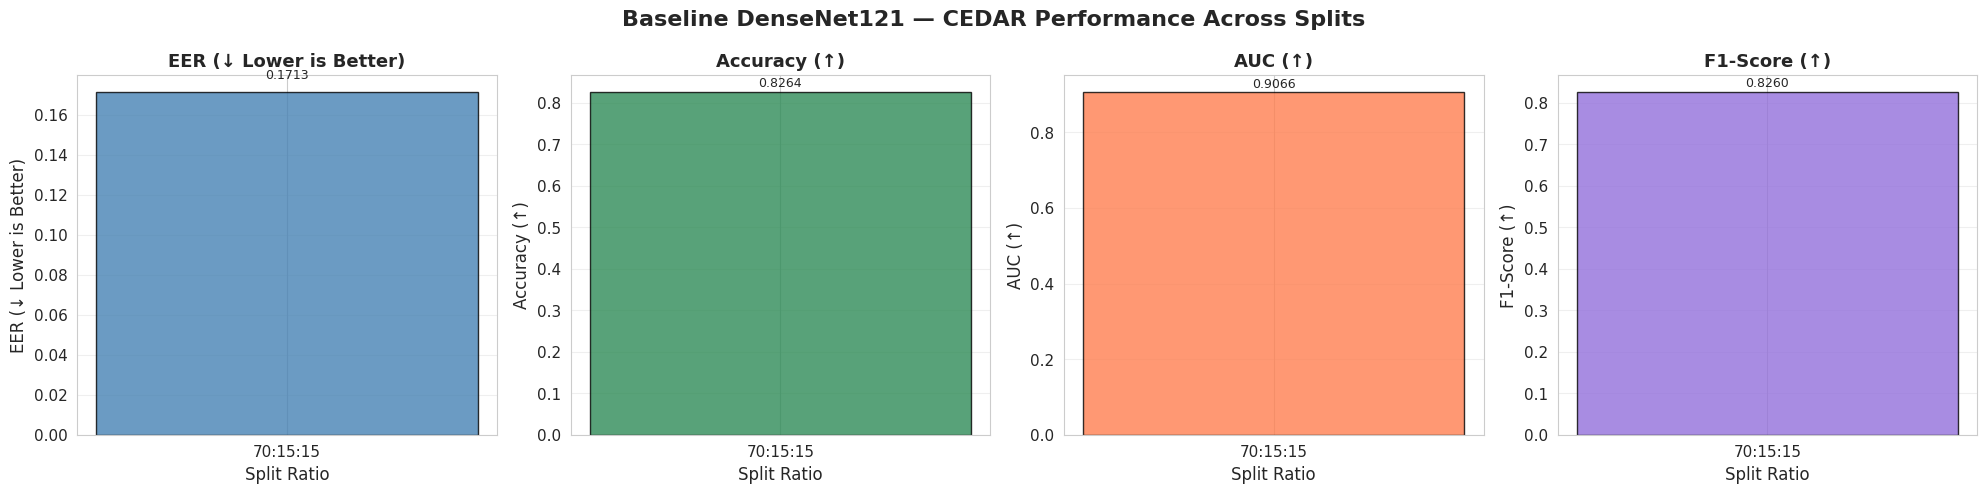

 > Plot saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_cedar_comparison.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Baseline DenseNet121 — {DATASET_NAME} Performance Across Splits',
             fontsize=16, fontweight='bold')

metrics_to_plot = ['eer', 'accuracy', 'auc', 'f1']
titles          = ['EER (↓ Lower is Better)', 'Accuracy (↑)', 'AUC (↑)', 'F1-Score (↑)']
colors          = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
    split_labels = []
    values       = []

    for ratio in SPLIT_RATIOS:
        split_str = ratio.replace('_', ':')
        split_labels.append(split_str)
        key = f"{DATASET_NAME} ({split_str})"
        values.append(all_results.get(key, {}).get(metric, 0))

    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved to: {plot_path}")